# Imports

In [1]:
import pandas as pd
import numpy as np
import pickle
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from keras.models import Model
from keras.layers import Input, Dense
from keras.optimizers import Adam
from keras.losses import MeanSquaredError
import matplotlib.pyplot as plt

import sys
sys.path.append('..')
from pipeline import (
    AUTOENCODER_FEATURES,
    AUTOENCODER_SCALE_COLS,
    filter_port,
)

# Load and preview distribution

In [18]:
df = pd.read_csv('../ryu-controller/traffic_log.csv')

# keep only normal traffic
df = df[df['Traffic'] == 'Normal']

# split by L4 protocol
df_icmp_prev = df[df['Ip_protocole'] == 'icmp'].copy()
df_tcp_prev  = df[df['Ip_protocole'] == 'tcp'].copy()
df_udp_prev  = df[df['Ip_protocole'] == 'udp'].copy()

print(f'ICMP: {len(df_icmp_prev)} | TCP: {len(df_tcp_prev)} | UDP: {len(df_udp_prev)}')
print(df.columns.tolist())

ICMP: 540 | TCP: 44340 | UDP: 2640
['Timestamp', 'Ip_src', 'Ip_dst', 'Same_ip', 'Port_src', 'Port_dst', 'Ip_protocole', 'Type_protocole', 'Icmp', 'Icmp_code', 'Icmp_type', 'Tcp', 'Udp', 'ACK', 'PSH', 'RST', 'SYN', 'FIN', 'Http', 'Ftp', 'Smtp', 'Dns', 'Flow_duration', 'Flow_dur_nsec', 'Packet_count', 'Bytes', 'Pkt_per_sec', 'Pkt_per_nsec', 'Bytes_per_sec', 'Bytes_per_nsec', 'Traffic', 'Attack_type']


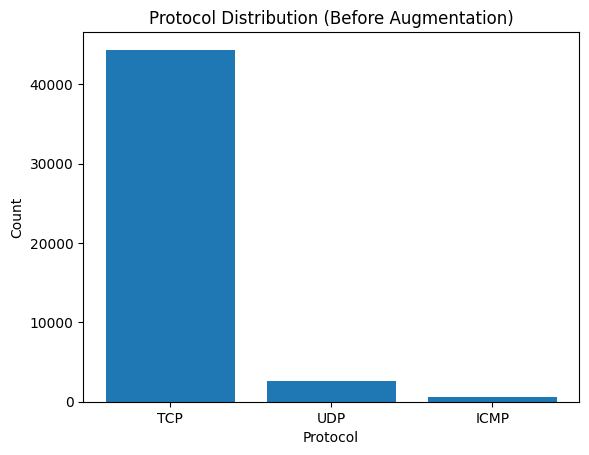

{'TCP': 44340, 'UDP': 2640, 'ICMP': 540}


In [19]:
counts = {
    "TCP": len(df_tcp_prev),
    "UDP": len(df_udp_prev),
    "ICMP": len(df_icmp_prev),
}

plt.figure()
plt.bar(counts.keys(), counts.values())
plt.title("Protocol Distribution (Before Augmentation)")
plt.xlabel("Protocol")
plt.ylabel("Count")
plt.show()

print(counts)

# Balancing dataset by augmentation (Mixup)

In [20]:
# Columns to mix (numeric only)
mix_cols = [
    "Packet_count",
    "Bytes",
    "Pkt_per_sec",
    "Bytes_per_sec",
    "Bytes_per_nsec"
]

In [21]:
# ICMP data
df_icmp_pre_aug = df[df["Icmp"] == 1].copy().reset_index(drop=True)

# Shuffle twice
df1 = df_icmp_pre_aug.sample(frac=1).reset_index(drop=True)
df2 = df_icmp_pre_aug.sample(frac=1).reset_index(drop=True)

# Mixing coefficient
lam = np.random.uniform(0.3, 0.7)

# Apply mixing
df_icmp_mix = df1.copy()
for col in mix_cols:
    if col in df_icmp_mix.columns:
        df_icmp_mix[col] = lam * df1[col] + (1 - lam) * df2[col]

df_aug = pd.concat([df, df_icmp_mix], ignore_index=True)

In [22]:
# UDP data
df_udp_pre_aug = df[df["Udp"] == 1].copy().reset_index(drop=True)

# Shuffle twice
df1 = df_udp_pre_aug.sample(frac=1).reset_index(drop=True)
df2 = df_udp_pre_aug.sample(frac=1).reset_index(drop=True)

# Mixing coefficient
lam = np.random.uniform(0.3, 0.7)

# Apply MixUp
df_udp_mix = df1.copy()
for col in mix_cols:
    if col in df_udp_mix.columns:
        df_udp_mix[col] = lam * df1[col] + (1 - lam) * df2[col]

df_aug = pd.concat([df_aug, df_udp_mix], ignore_index=True)

In [23]:
counts_aug = {
    "TCP": df_aug["Tcp"].sum(),
    "UDP": df_aug["Udp"].sum(),
    "ICMP": df_aug["Icmp"].sum()
}

print(counts_aug)

{'TCP': np.int64(44340), 'UDP': np.int64(5280), 'ICMP': np.int64(1080)}


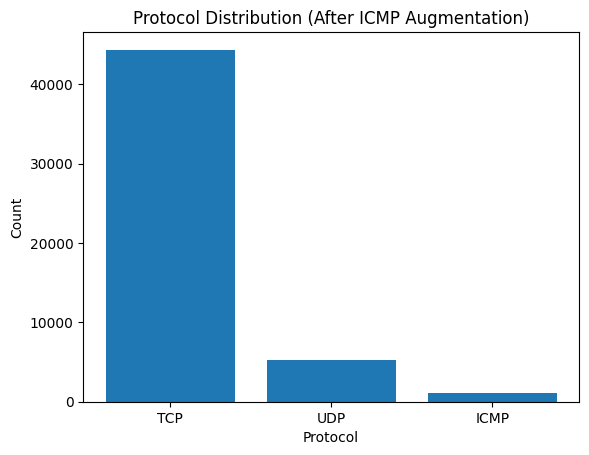

{'TCP': np.int64(44340), 'UDP': np.int64(5280), 'ICMP': np.int64(1080)}


In [24]:
plt.figure()
plt.bar(counts_aug.keys(), counts_aug.values())
plt.title("Protocol Distribution (After ICMP Augmentation)")
plt.xlabel("Protocol")
plt.ylabel("Count")
plt.show()

print(counts_aug)

# Split by protocol

In [27]:
df_icmp = df_aug[df_aug['Ip_protocole'] == 'icmp'].copy()
df_tcp  = df_aug[df_aug['Ip_protocole'] == 'tcp'].copy()
df_udp  = df_aug[df_aug['Ip_protocole'] == 'udp'].copy()

# Preprocessing function

In [14]:
def preprocess_protocol(df, protocol):
    """Select features, filter ports, scale, return array + fitted scaler."""
    feature_cols = AUTOENCODER_FEATURES[protocol]
    scale_cols   = AUTOENCODER_SCALE_COLS[protocol]

    X = df[feature_cols].copy()

    # port filtering
    if 'Port_dst' in X.columns:
        X['Port_dst'] = X['Port_dst'].apply(filter_port)

    # drop missing
    X = X.dropna()

    # fit scaler on scale columns only
    scaler = StandardScaler()
    X[scale_cols] = scaler.fit_transform(X[scale_cols].values)

    return X.values.astype(np.float32), scaler

# Autoencoder builder

In [15]:
def build_autoencoder(input_dim):
    """Simple dense autoencoder, bottleneck at 1/4 input size."""
    inp       = Input(shape=(input_dim,))
    encoded   = Dense(input_dim * 2, activation='relu')(inp)
    bottleneck= Dense(input_dim // 4, activation='relu')(encoded)
    decoded   = Dense(input_dim * 2, activation='relu')(bottleneck)
    out       = Dense(input_dim, activation='linear')(decoded)

    model = Model(inp, out)
    model.compile(optimizer=Adam(learning_rate=0.001), loss=MeanSquaredError())
    return model

# Train one protocol

In [16]:
def train_and_save(df, protocol):
    print(f'\n---{protocol.upper()} ---')

    if len(df) < 30:
        print(f'Not enough samples ({len(df)}), skipping...')
        return None, None

    X, scaler = preprocess_protocol(df, protocol)
    X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

    model = build_autoencoder(X_train.shape[1])
    model.fit(
        X_train, X_train,
        epochs=50,
        batch_size=32,
        validation_data=(X_test, X_test),
        verbose=1,
    )

    # compute RMSE on test set to pick threshold
    X_pred = model.predict(X_test)
    mse    = np.mean(np.power(X_test - X_pred, 2), axis=1)
    rmse   = np.sqrt(mse)

    threshold = np.percentile(rmse, 95)
    print(f'Suggested threshold (95th percentile): {threshold:.4f}')

    # plot
    plt.figure()
    plt.hist(rmse, bins=50)
    plt.axvline(threshold, color='red', label=f'threshold={threshold:.4f}')
    plt.title(f'{protocol.upper()} reconstruction error distribution')
    plt.xlabel('RMSE')
    plt.legend()
    plt.show()

    # save model only
    model.save(f'../ryu-controller/{protocol}.h5')
    print(f'Saved {protocol}.h5')

    return threshold, scaler

# Start Traingin


---ICMP ---
Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2358 - val_loss: 0.2227
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1808 - val_loss: 0.1566
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1236 - val_loss: 0.1024
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0836 - val_loss: 0.0672
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0561 - val_loss: 0.0411
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0375 - val_loss: 0.0274
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0252 - val_loss: 0.0166
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0141 - val_loss: 0.0080
Epoch 9/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0063 - val_loss: 0.0040
Epoch 10/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0031 - val_loss: 0.0022
Epoch 11/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0018 - val_loss: 0.0015
Epoch 12/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.

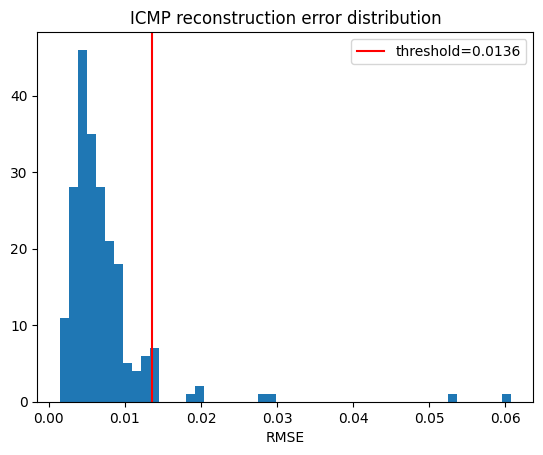

Saved icmp.h5


In [31]:
threshold_icmp, scaler_icmp = train_and_save(df_icmp, 'icmp')


---TCP ---
Epoch 1/50
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0945 - val_loss: 0.0258
Epoch 2/50
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0175 - val_loss: 0.0125
Epoch 3/50
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0103 - val_loss: 0.0084
Epoch 4/50
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0078 - val_loss: 0.0070
Epoch 5/50
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0068 - val_loss: 0.0061
Epoch 6/50
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0061 - val_loss: 0.0056
Epoch 7/50
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0055 - val_loss: 0.0050
Epoch 8/50
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0049 - val_loss: 0.0046
Epoch 9/50
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0044 - val_loss: 0.0045
Epoch 10/50
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0041 - val_loss: 0.0039
Epoch 11/50
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0038 - val_loss: 0.0037
Epoch 12/50
1109/1

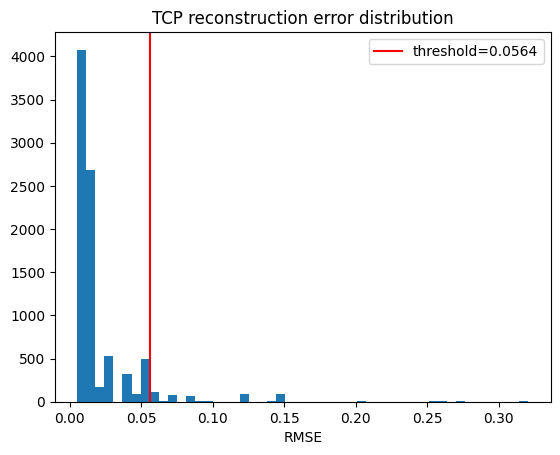

Saved tcp.h5


In [32]:
threshold_tcp, scaler_tcp = train_and_save(df_tcp, 'tcp')


---UDP ---
Epoch 1/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 57.1587 - val_loss: 0.3222
Epoch 2/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1415 - val_loss: 0.1248
Epoch 3/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0879 - val_loss: 0.0969
Epoch 4/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0758 - val_loss: 0.0907
Epoch 5/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0726 - val_loss: 0.0913
Epoch 6/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0721 - val_loss: 0.0887
Epoch 7/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0715 - val_loss: 0.0882
Epoch 8/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0712 - val_loss: 0.0877
Epoch 9/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0709 - val_loss: 0.0881
Epoch 10/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0708 - val_loss: 0.0880
Epoch 11/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0710 - val_loss: 0.0881
Epoch 12/50
132/132 ━━━━━━━━━━━━━━━━━━━

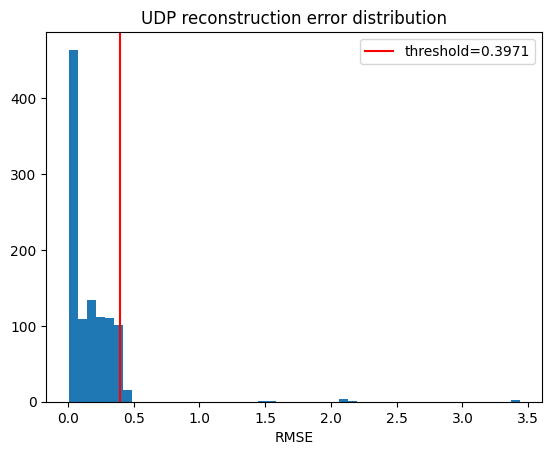

Saved udp.h5


In [33]:
threshold_udp, scaler_udp = train_and_save(df_udp, 'udp')

### Here I converted the models to .onnx for compatibility with RYU during runtime. `h5` files are used by keras, which comes with Tensorflow, but since I am using python 3.8 for RYU, there will be compatibility issues with Tensorflow, so I will use ONNX format which is more universal and can be used with different frameworks

In [36]:
import tf2onnx
import onnx
from keras.models import load_model

for proto in ('icmp', 'tcp', 'udp'):
    model = load_model(f'../ryu-controller/{proto}.h5')
    onnx_model, _ = tf2onnx.convert.from_keras(model, opset=13)
    onnx.save(onnx_model, f'../ryu-controller/{proto}.onnx')
    print(f'Saved {proto}.onnx')

Saved icmp.onnx
Saved tcp.onnx


Saved udp.onnx


# Saving Scalers

### Pickling as standard way of saving. But the the issue is it saves numpy arrays as well, and I am using python 3.8 (venv) for RYU, so this will break the code. i kept only because it is the standard way.

In [34]:
for protocol in ('icmp', 'tcp', 'udp'):
    with open(f'../ryu-controller/std_{protocol}.pkl', 'wb') as f:
        pickle.dump(locals().get(f'scaler_{protocol}'), f)

    print(f'Saved {protocol}.h5 and std_{protocol}.pkl')

Saved icmp.h5 and std_icmp.pkl
Saved tcp.h5 and std_tcp.pkl
Saved udp.h5 and std_udp.pkl


### In order to solve that isee, I saved the scalers manually as json files, so i can skip saving the numpy arrays. I will load these json files in RYU and create the scalers there.

In [35]:
import json

scalers = {
    'icmp': scaler_icmp,
    'tcp':  scaler_tcp,
    'udp':  scaler_udp,
}

for proto, scaler in scalers.items():
    scaler_data = {
        'mean':            scaler.mean_.tolist(),
        'scale':           scaler.scale_.tolist(),
        'var':             scaler.var_.tolist(),
        'n_samples_seen':  int(scaler.n_samples_seen_),
    }
    with open(f'../ryu-controller/std_{proto}.json', 'w') as f:
        json.dump(scaler_data, f)
    print(f'Saved std_{proto}.json')

Saved std_icmp.json
Saved std_tcp.json
Saved std_udp.json


# Print final thresholds to update in monitor.py

In [37]:
print(f'\nUpdate these in monitor.py:')
print(f'THRESHOLD_ICMP = {threshold_icmp:.4f}')
print(f'THRESHOLD_TCP  = {threshold_tcp:.4f}')
print(f'THRESHOLD_UDP  = {threshold_udp:.4f}')


Update these in monitor.py:
THRESHOLD_ICMP = 0.0136
THRESHOLD_TCP  = 0.0564
THRESHOLD_UDP  = 0.3971
